In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud
import matplotlib

# Prevent $ parsing crash
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['mathtext.default'] = 'regular'

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (8,5)

# Load dataset (change path if needed)
amazon_sent_train = pd.read_csv('train_sentences.csv')
amazon_sent_test = pd.read_csv('test_sentences.csv')

amazon = pd.concat([amazon_sent_train, amazon_sent_test], ignore_index=True)
amazon.head()

# Clean $ to avoid plotting issues
amazon['sentence'] = amazon['sentence'].astype(str).str.replace('$', '', regex=False)

amazon.head()


,id,sentence,label
0,0,This sound track was beautiful!,2
1,0,It paints the senery in your mind so well I wo...,2
2,0,game music!,2
3,0,I have played the game Chrono Cross but out of...,2
4,0,It backs away from crude keyboarding and takes...,2


Dataset Shape: (18673747, 3)

Missing Values:
 id          0
sentence    0
label       0
dtype: int64

Label Distribution:
 label
1    9707675
2    8966072
Name: count, dtype: int64


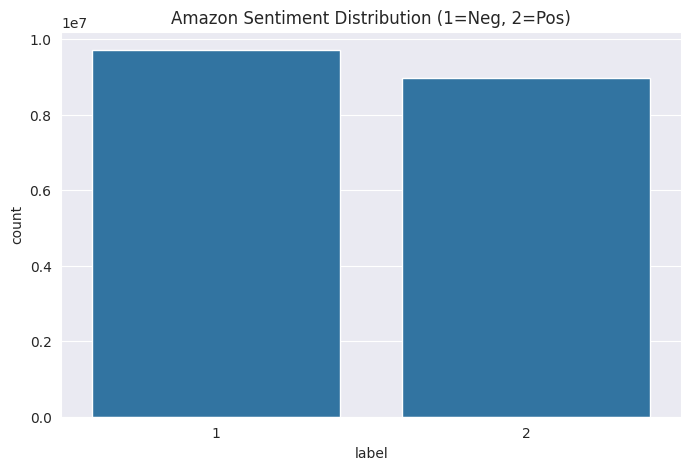

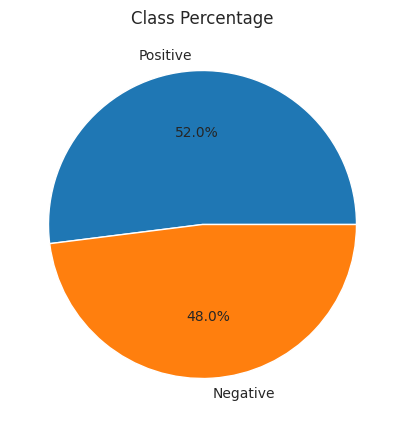

In [2]:
#Basic Dataset Overview
print("Dataset Shape:", amazon.shape)
print("\nMissing Values:\n", amazon.isnull().sum())
print("\nLabel Distribution:\n", amazon['label'].value_counts())

# Countplot
plt.figure()
sns.countplot(x='label', data=amazon)
plt.title("Amazon Sentiment Distribution (1=Neg, 2=Pos)")
plt.show()

print()
print()
# Pie Chart
plt.figure()
plt.pie(amazon['label'].value_counts(),
        labels=['Positive','Negative'] if 2 in amazon['label'].values else amazon['label'].unique(),
        autopct='%1.1f%%')
plt.title("Class Percentage")
plt.show()


Sentence Length Analysis (Important for BERT)

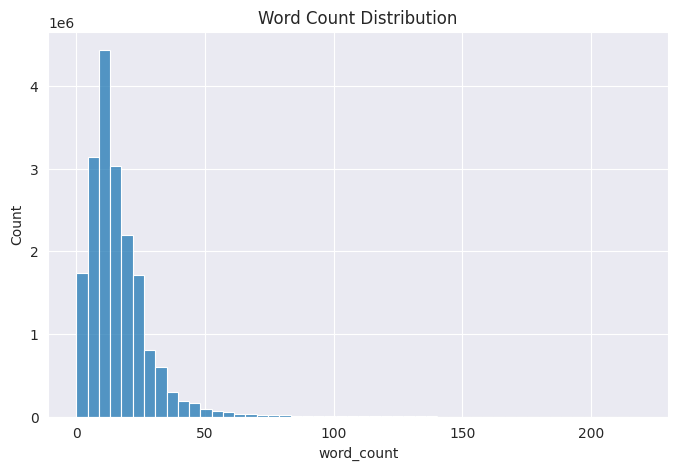

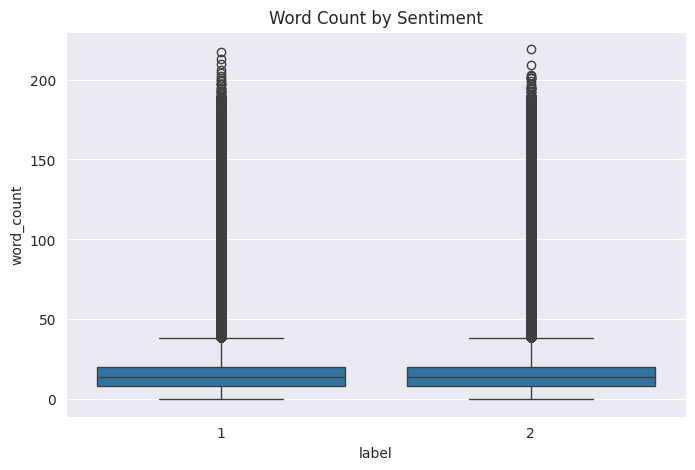

In [3]:
amazon['char_length'] = amazon['sentence'].apply(len)
amazon['word_count'] = amazon['sentence'].apply(lambda x: len(x.split()))

# Histogram
plt.figure()
sns.histplot(amazon['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.show()

print()
# Boxplot by Label
plt.figure()
sns.boxplot(x='label', y='word_count', data=amazon)
plt.title("Word Count by Sentiment")
plt.show()


HEATMAP: Correlation Matrix

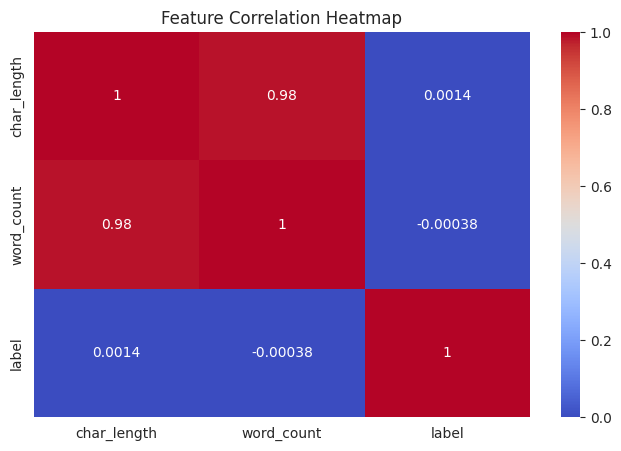

In [4]:
corr = amazon[['char_length','word_count','label']].corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


HEATMAP: Label vs Length (Grouped Mean)

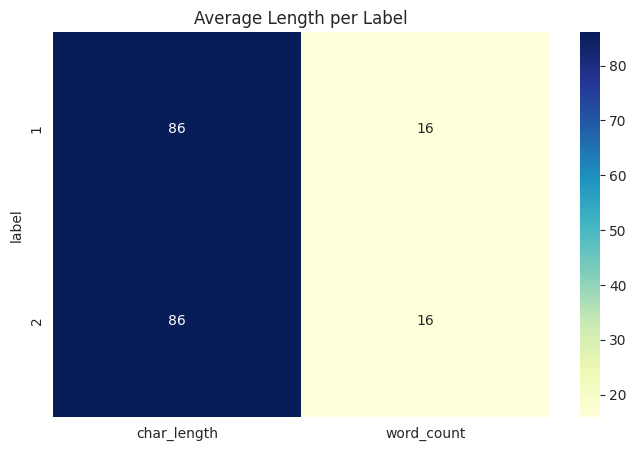

In [5]:
grouped = amazon.groupby('label')[['char_length','word_count']].mean()

plt.figure()
sns.heatmap(grouped, annot=True, cmap='YlGnBu')
plt.title("Average Length per Label")
plt.show()


Top Words (Bar Plot)

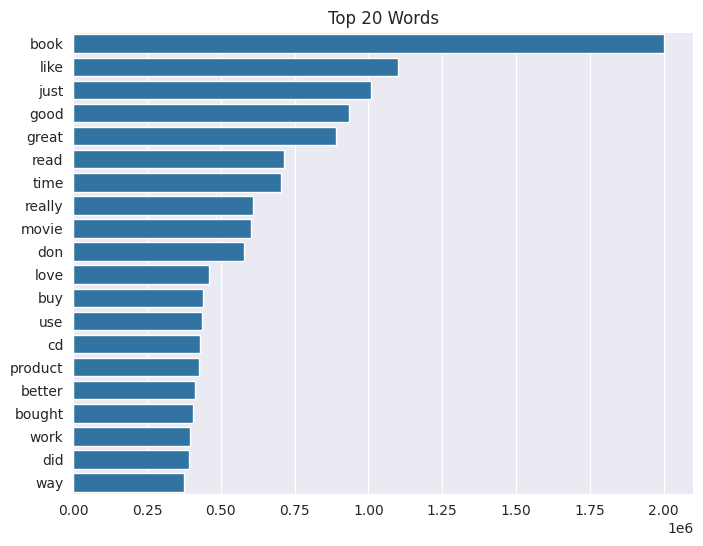

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20
)

X = vectorizer.fit_transform(amazon['sentence'])

word_counts = X.sum(axis=0).A1
words = vectorizer.get_feature_names_out()

# Sort
sorted_idx = word_counts.argsort()[::-1]
words = words[sorted_idx]
word_counts = word_counts[sorted_idx]

plt.figure(figsize=(8,6))
sns.barplot(x=word_counts, y=words)
plt.title("Top 20 Words")
plt.show()


HEATMAP: Bigram Frequency Matrix

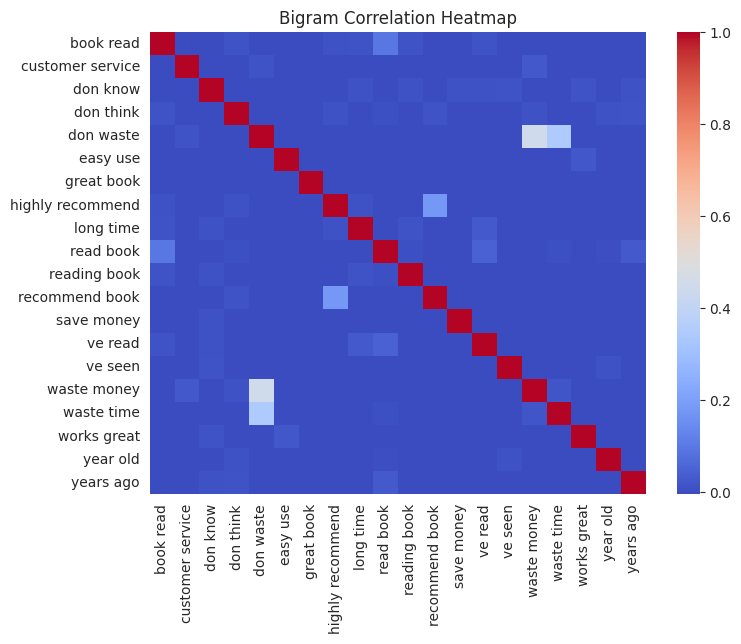

In [7]:
sample_data = amazon['sentence'].sample(30000, random_state=42)

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words='english',
    max_features=20
)

X = vectorizer.fit_transform(sample_data)

# Convert ONLY feature matrix (20 columns) safely
X_small = X.toarray()

# Correlation between features
corr_matrix = np.corrcoef(X_small, rowvar=False)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            xticklabels=vectorizer.get_feature_names_out(),
            yticklabels=vectorizer.get_feature_names_out(),
            cmap='coolwarm')
plt.title("Bigram Correlation Heatmap")
plt.show()


TF-IDF Feature Heatmap (For SVM / Logistic Regression)

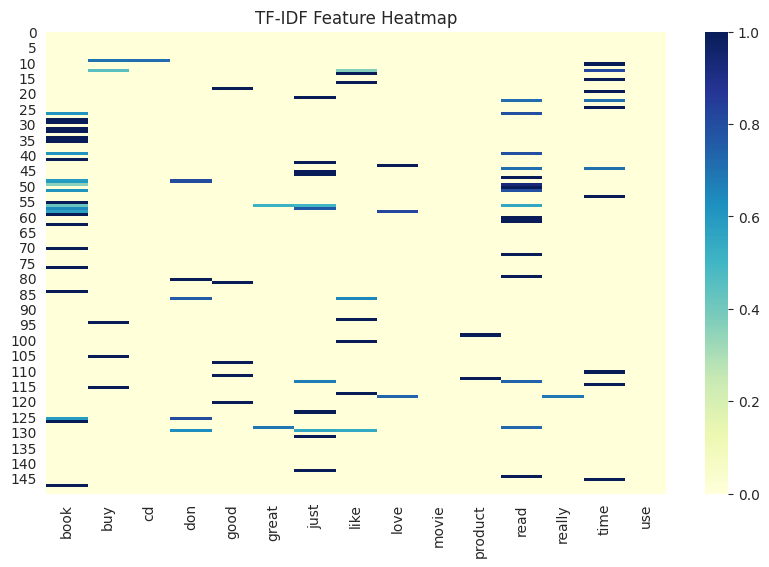

In [8]:
tfidf = TfidfVectorizer(max_features=15, stop_words='english')
X_tfidf = tfidf.fit_transform(amazon['sentence'])

tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Show first 50 documents for clarity
plt.figure(figsize=(10,6))
sns.heatmap(tfidf_df.head(150), cmap='YlGnBu')
plt.title("TF-IDF Feature Heatmap")
plt.show()


WordCloud by Polarity

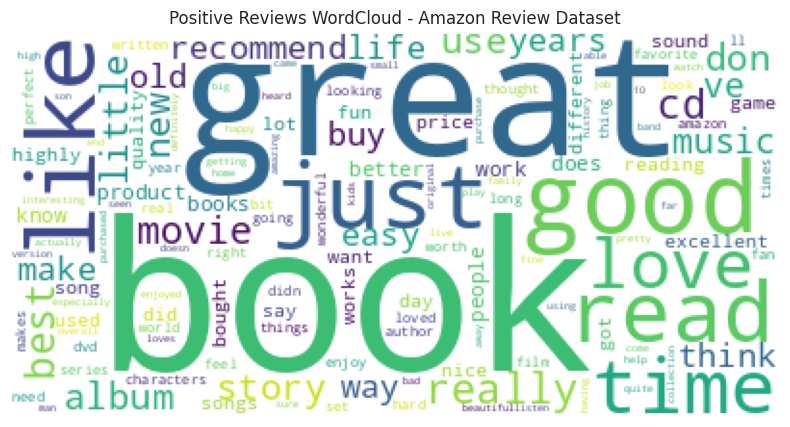

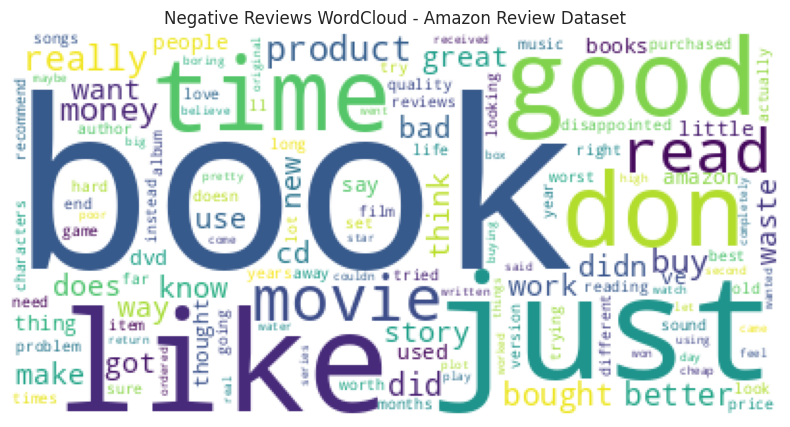

In [11]:
# Sample to prevent RAM crash
sample_pos = amazon[amazon['label']==2]['sentence'].sample(20000, random_state=42)
sample_neg = amazon[amazon['label']==1]['sentence'].sample(20000, random_state=42)

# Use CountVectorizer to get frequencies (memory efficient)
vectorizer = CountVectorizer(stop_words='english', max_features=500)

# Positive
X_pos = vectorizer.fit_transform(sample_pos)
freq_pos = dict(zip(vectorizer.get_feature_names_out(), X_pos.sum(axis=0).A1))

plt.figure(figsize=(10,5))
wc = WordCloud(background_color='white', max_words=200)
wc.generate_from_frequencies(freq_pos)
plt.imshow(wc)
plt.axis('off')
plt.title("Positive Reviews WordCloud - Amazon Review Dataset")
plt.show()
print()
# Negative
X_neg = vectorizer.fit_transform(sample_neg)
freq_neg = dict(zip(vectorizer.get_feature_names_out(), X_neg.sum(axis=0).A1))

plt.figure(figsize=(10,5))
wc = WordCloud(background_color='white', max_words=200)
wc.generate_from_frequencies(freq_neg)
plt.imshow(wc)
plt.axis('off')
plt.title("Negative Reviews WordCloud - Amazon Review Dataset")
plt.show()

Document-Level Aggregation (For our Pipeline)

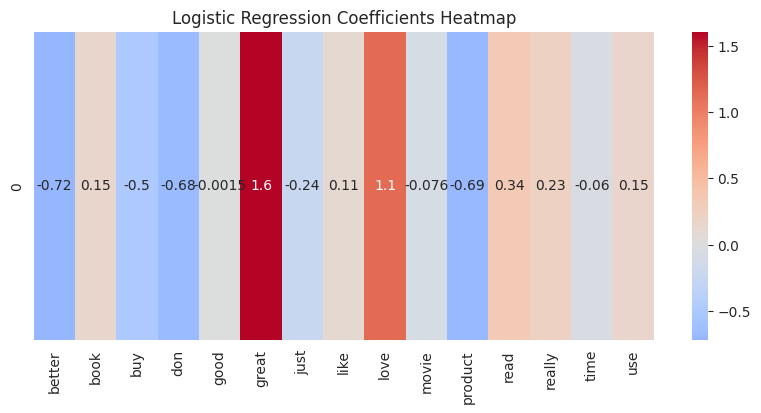

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
# Aggregate sentences into document-level text
X = tfidf.fit_transform(amazon['sentence'].sample(10000, random_state=42))
y = amazon['label'].sample(10000, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

coef = pd.DataFrame(model.coef_, columns=tfidf.get_feature_names_out())

plt.figure(figsize=(10,4))
sns.heatmap(coef, annot=True, cmap='coolwarm', center=0)
plt.title("Logistic Regression Coefficients Heatmap")
plt.show()
